# **KNN**

In [3]:
import pandas as pd
import numpy as np
from collections import Counter

In [22]:
# Euclidean distance function
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

In [23]:
def knn_predict(training_data, training_labels, test_point, k):
    distances = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i])
        distances.append((dist, training_labels[i]))  # store (distance, label)
    distances.sort(key=lambda x: x[0])  # sort by distance
    k_nearest_labels = [label for _, label in distances[:k]]  # extract labels
    return Counter(k_nearest_labels).most_common(1)[0][0]

In [26]:
training_data = [[1,2],[2,3],[3,4],[6,7],[7,8]]
training_labels = ['A','A','A','B','B']
test_point = [4,4]
k = 3

In [28]:
prediction = knn_predict(training_data, training_labels, test_point, k)
print("Predicted label:", prediction)

Predicted label: A


# **Conditional Probability**

**depends upon the condition which have already occured**

we denote it by:

**p(B | A) = p(B intersection A) / P(A)**

**Eg: Suppose 100 jana diyiyeko xa; 50 jana le football khelxa ra 30 jana le football + basketball khelxan; only basketball khelney kati jana?**

In [29]:
30 / 50

0.6

# **Bayes Theorem**

**eg: 2 bag; bagA = 3R and 1B; bagB = 1R and 3B;suppose you get red. From which bag did you get that?**

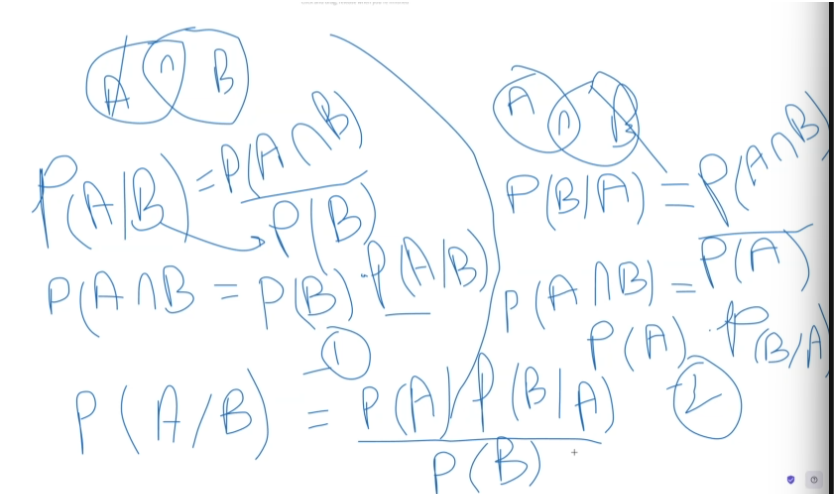

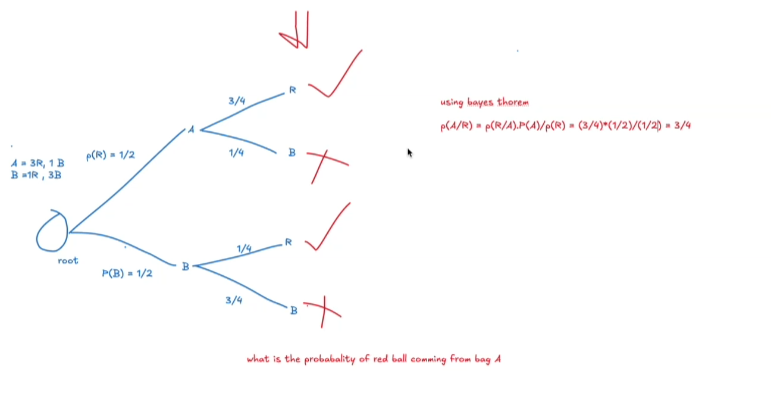

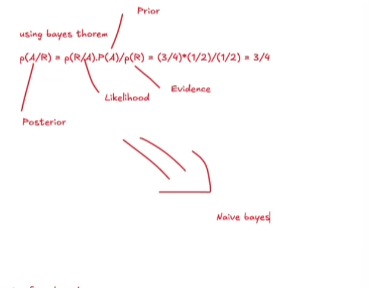

# **Naive Bayes Classifiers**

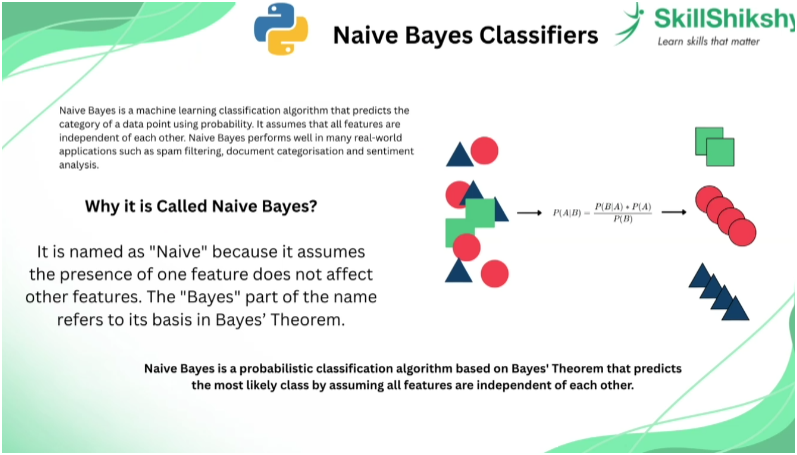

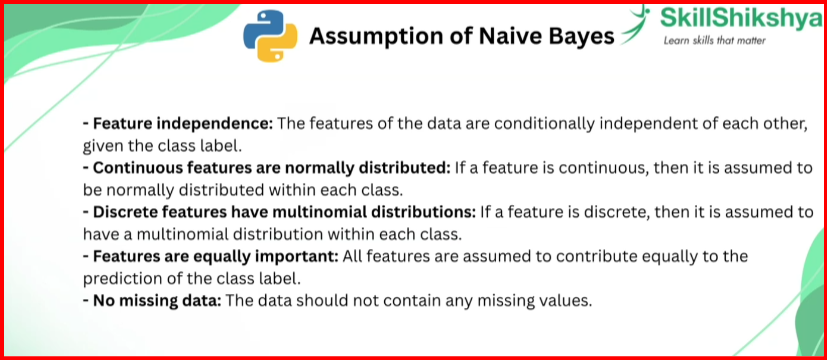

In [31]:
import pandas as pd
data = {
    "Outlook": ["Rainy", "Rainy", "Overcast", "Sunny", "Sunny", "Sunny", "Overcast", "Rainy", "Rainy", "Sunny", "Rainy", "Overcast", "Overcast", "Sunny"],
    "Temperature": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool", "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "Humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal", "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "Windy": [False, True, False, False, False, True, True, False, False, False, True, True, False, True],
    "Play Golf": ["No", "No", "Yes", "Yes", "Yes", "No", "Yes", "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"]
}
df = pd.DataFrame(data)

df.head()


,Outlook,Temperature,Humidity,Windy,Play Golf
0,Rainy,Hot,High,False,No
1,Rainy,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Sunny,Mild,High,False,Yes
4,Sunny,Cool,Normal,False,Yes


**Label encoding**

In [32]:
from sklearn.preprocessing import LabelEncoder
encoded_df = pd.DataFrame()

for each in df.columns:
  encoder = LabelEncoder()
  encoded_df[each] = encoder.fit_transform(df[each])
  print(f"For {each} : {encoder.classes_}")

For Outlook : ['Overcast' 'Rainy' 'Sunny']
For Temperature : ['Cool' 'Hot' 'Mild']
For Humidity : ['High' 'Normal']
For Windy : [False  True]
For Play Golf : ['No' 'Yes']


In [38]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [39]:
X = encoded_df.drop(columns='Play Golf', axis=1).to_numpy()
y = encoded_df['Play Golf'].to_numpy()

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Initialize and fit the classifier
classifier = CategoricalNB()
classifier.fit(X_train, y_train)

# Predictions
y_pred = classifier.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Example: predict for a new sample
sample = np.array([[2, 1, 0, 1]])  # replace with actual encoded values
prediction = classifier.predict(sample)
print("Prediction for sample:", prediction[0])

Accuracy: 0.6

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5

Prediction for sample: 0
